# 📊 Telecom Customer Churn Analysis
### Identifying At-Risk Segments & Revenue Drivers

---

## 🎯 Project Overview & Goal
The objective of this project is to analyze customer churn for an IBM Telecom dataset, identify high-risk customer segments, calculate revenue loss, and provide actionable data-driven strategies to improve customer retention.

---

## 📁 Dataset Overview
* **Source:** IBM Telco Customer Churn Dataset
* **Size:** 7,043 Records (Customers) | 33 Attributes
* **Key Features:**
  * **Demographics:** Gender, Senior Citizen, Partner, Dependents
  * **Account Info:** Tenure Months, Contract Type, Payment Method, Monthly Charges, Total Charges, CLTV
  * **Services Subscribed:** Phone, Multiple Lines, Internet Service (DSL/Fiber Optic), Security, Support, Streaming
  * **Target Variables:** Churn Value (0/1), Churn Reason, Churn Score

---

## ⚡ Key Metrics & Key Takeaways

* **Overall Churn Rate:** **26.54%** (1,869 out of 7,043 customers churned).
* **Total Revenue Impact:**
  * **Total Revenue:** ~$16.06 Million
  * **Revenue Lost to Churn:** High concentration in Month-to-Month contracts (~12% total revenue lost) and Electronic Check users (~9.76% total revenue lost).
* **Highest-Risk Tenure Segment:** Customers in their **first 6 months** experience an alarming **52.94% churn rate**.
* **High-Risk Service Segment:** **Fiber Optic** internet subscribers have a **41.89% churn rate** (compared to 18.96% for DSL).
* **Retention Drivers:** 2-Year contracts, Automatic payment methods (Bank Transfer / Credit Card), and subscribing to Tech Support / Online Security significantly reduce churn risk.

### Import Libraries

In [1]:
import sqlite3 # Import SQL enviroment for doing complicated analysis using simple query
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Create a connection to an in-memory SQL database
conn = sqlite3.connect(':memory:')

In [3]:
# Load the data file

df = pd.read_excel('Telco_customer_churn.xlsx')

In [4]:
# First Five rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
print(f'The value of rows and columns in this data are {df.shape}')

The value of rows and columns in this data are (7043, 33)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

### Data Cleaning

In [7]:
# Change the data types

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [8]:
print("Missing values in TotalCharges:", df['Total Charges'].isnull().sum())

Missing values in TotalCharges: 11


In [9]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [10]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [11]:
# Checking missing values

df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [12]:
# Checking for duplicatesabs
df.duplicated().sum()

np.int64(0)

In [13]:
# this approch is prefered to check why the total charges have 0 values so after seeing this i find the tenure months also have 0 that means these are the new subscribers which just join the company.

df[df['Tenure Months'] == 0][['Tenure Months', 'Monthly Charges', 'Total Charges']]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,0.0
2438,0,20.25,0.0
2568,0,80.85,0.0
2667,0,25.75,0.0
2856,0,56.05,0.0
4331,0,19.85,0.0
4687,0,25.35,0.0
5104,0,20.00,0.0
5719,0,19.70,0.0
6772,0,73.35,0.0


### Checking the misconsumption in the data

In [14]:
# It will show unique value in all categorical columns

categorical_cols = df.select_dtypes(include=['str']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:5]}") # Checks a sample of unique values

CustomerID: <StringArray>
['3668-QPYBK', '9237-HQITU', '9305-CDSKC', '7892-POOKP', '0280-XJGEX']
Length: 5, dtype: str
Country: <StringArray>
['United States']
Length: 1, dtype: str
State: <StringArray>
['California']
Length: 1, dtype: str
City: <StringArray>
['Los Angeles', 'Beverly Hills', 'Huntington Park', 'Lynwood',
 'Marina Del Rey']
Length: 5, dtype: str
Lat Long: <StringArray>
['33.964131, -118.272783',  '34.059281, -118.30742', '34.048013, -118.293953',
 '34.062125, -118.315709', '34.039224, -118.266293']
Length: 5, dtype: str
Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Senior Citizen: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Partner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Phone Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Multiple Lines: <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
Internet Service: <StringArray>
['DSL', 'Fiber optic', 'N

In [15]:
print(pd.crosstab(df['Internet Service'], df['Online Security']))

Online Security     No  No internet service   Yes
Internet Service                                 
DSL               1241                    0  1180
Fiber optic       2257                    0   839
No                   0                 1526     0


In [16]:
internet_addons = ['Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for addon in internet_addons:
    print(f"\n--- Crosstab for {addon} ---")
    print(pd.crosstab(df['Internet Service'], df[addon])) # This ensure that the data makes sense logically across columns.


--- Crosstab for Online Backup ---
Online Backup       No  No internet service   Yes
Internet Service                                 
DSL               1335                    0  1086
Fiber optic       1753                    0  1343
No                   0                 1526     0

--- Crosstab for Device Protection ---
Device Protection    No  No internet service   Yes
Internet Service                                  
DSL                1356                    0  1065
Fiber optic        1739                    0  1357
No                    0                 1526     0

--- Crosstab for Tech Support ---
Tech Support        No  No internet service   Yes
Internet Service                                 
DSL               1243                    0  1178
Fiber optic       2230                    0   866
No                   0                 1526     0

--- Crosstab for Streaming TV ---
Streaming TV        No  No internet service   Yes
Internet Service                                 

In [17]:
# Drop unusual columns
cols = ['Country', 'State']

df.drop(columns=cols, inplace=True)


In [18]:
df.drop(columns=['Count', 'Lat Long'], inplace=True)

In [19]:
df.to_csv('IBM_churn.csv', index=False)

## Start the Analysis

In [20]:
# 1. Load clean CSV file back into Pandas
clean_df = pd.read_csv('IBM_churn.csv')

# 3. Write clean DataFrame into the SQL database as a table named 'ibm_churn'
clean_df.to_sql('ibm_churn', conn, index=False, if_exists='replace')

query1 = """
SELECT 
	COUNT(DISTINCT CustomerID) AS Total_Customers,
    SUM([Churn Value]) AS Total_churned_Customers,
	ROUND(AVG([Monthly Charges]),2) AS Avg_monthly_charge,
    ROUND(AVG([Total Charges]),2) AS Avg_total_charge
    
FROM ibm_churn;
"""
Excutive_summary = pd.read_sql(query1, conn)
Excutive_summary


,Total_Customers,Total_churned_Customers,Avg_monthly_charge,Avg_total_charge
0,7043,1869,64.76,2279.73


In [21]:
print('EXECUTIVE SUMMARY')
print('='*50)

# Churn Rate
Churn_rate = df['Churn Value'].mean()*100
print(f'📉 Churn Rate = {round(Churn_rate,2)} %')

# Retation Rate
retention = 100 - Churn_rate
print(f'📈 Retention Rate = {round(retention, 2)} %')

# Total Revenue
total_revenue = df['Total Charges'].sum()
print(f'💰 Total Revenue = {total_revenue}')

# Total Revenue lost due to churn
churned_df = df[df['Churn Value'] == 1]
total_revenue = churned_df['Total Charges'].sum()
print(f'💰 Total Revenue Lost = {total_revenue}')

print('='*50)


EXECUTIVE SUMMARY
📉 Churn Rate = 26.54 %
📈 Retention Rate = 73.46 %
💰 Total Revenue = 16056168.7
💰 Total Revenue Lost = 2862926.9


## Perform EDA

### 1. Financial Risk & Optimization

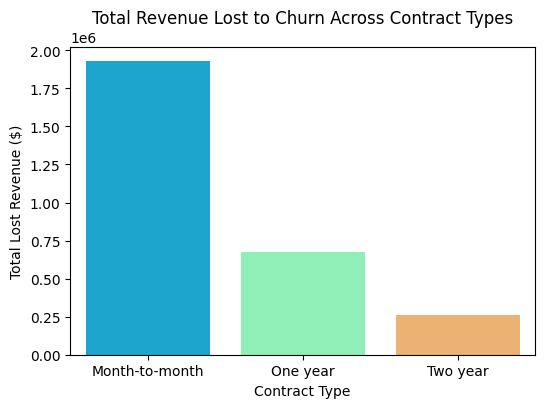

In [22]:
# Filter for only churned customers
churned_df = df[df['Churn Value'] == 1]

# Calculate total lost revenue per contract type
revenue_lost = churned_df.groupby('Contract')['Total Charges'].sum().reset_index()

# Plot the data
plt.figure(figsize=(6,4))
sns.barplot(
    data=revenue_lost, 
    x='Contract', 
    y='Total Charges', 
    palette='rainbow'
)
plt.title('Total Revenue Lost to Churn Across Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Total Lost Revenue ($)')
plt.show()

### Insights
1. 12% of total revenue was lost from customers who preferred the "Month-to-Month" contract type.
2. Approximately 4% of total revenue was lost due to customers with the "One-Year" contract type.
3. The "Two-Year" contract type accounts for only ~1% of total revenue loss, indicating that customers with long-term contracts have the lowest churn rate.

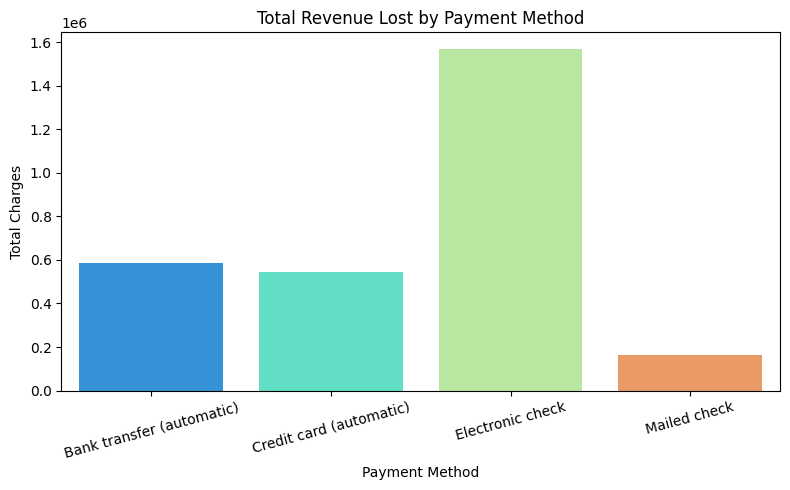

In [23]:
# 1. Filter for only churned customers
churned_df = df[df['Churn Value'] == 1]

# 2. Calculate total lost revenue per payment method
revenue_lost = churned_df.groupby('Payment Method')['Total Charges'].sum().reset_index()

# 3. Plot the data
plt.figure(figsize=(8, 5))  # Slightly wider to fit payment method labels
sns.barplot(
    data=revenue_lost, 
    x='Payment Method', 
    y='Total Charges', 
    palette='rainbow'
)
plt.title('Total Revenue Lost by Payment Method')
plt.xticks(rotation=15)  # Rotates long labels like "Bank transfer (automatic)" so they don't overlap
plt.tight_layout()
plt.show()

### Insights
1. Electronic Check: Customers using Electronic Check contribute the highest revenue loss due to churn, accounting for approximately 9.76% of total revenue. This indicates that customers paying via Electronic Check have the highest churn tendency.
2. Bank Transfer (Automatic): Customers using Bank Transfer (Automatic) account for approximately 3.65% of total revenue loss, reflecting a relatively lower churn impact than Electronic Check users.

3. Credit Card (Automatic): Customers paying through Credit Card (Automatic) contribute approximately 3.40% of total revenue loss, suggesting that automatic payment methods are associated with better customer retention.

4. Mailed Check: Customers using Mailed Check account for only 1.02% of total revenue loss, representing the lowest revenue loss among all payment methods.

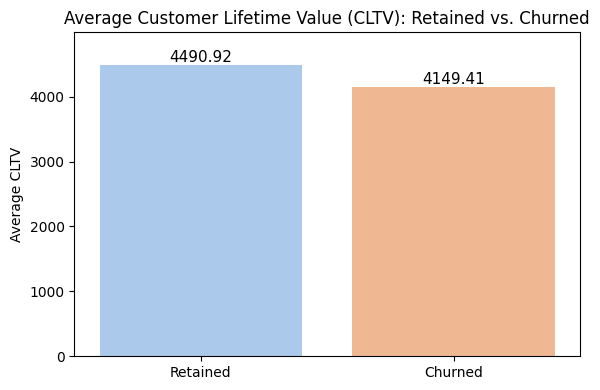

In [24]:
# 1. Calculate the average CLTV for retained vs churned customers
cltv_comparison = df.groupby('Churn Value')['CLTV'].mean().reset_index()

# Map 0 and 1 to readable text labels
cltv_comparison['Customer Status'] = cltv_comparison['Churn Value'].map({0: 'Retained', 1: 'Churned'})

# 2. Plot the comparison
plt.figure(figsize=(6,4))
sns.barplot(
    data=cltv_comparison, 
    x='Customer Status', 
    y='CLTV', 
    palette='pastel'
)

# Add value labels on top of the bars
for index, row in cltv_comparison.iterrows():
    plt.text(index, row['CLTV'] + 50, f"{row['CLTV']:.2f}", ha='center', fontsize=11)

plt.title('Average Customer Lifetime Value (CLTV): Retained vs. Churned')
plt.ylabel('Average CLTV')
plt.xlabel('')
plt.ylim(0, cltv_comparison['CLTV'].max() + 500)  # Adds extra space at the top for labels
plt.tight_layout()
plt.show()

### 2. Customer Behavior & Profile

Tenure_Cohort,Total_Customers,Churned_Customers,Churn_Rate_Percent
0-6 Months,1481,784,52.940000
6-12 Months,705,253,35.890000
1-2 Years,1024,294,28.710000
More than 2 Years,3833,538,14.040000


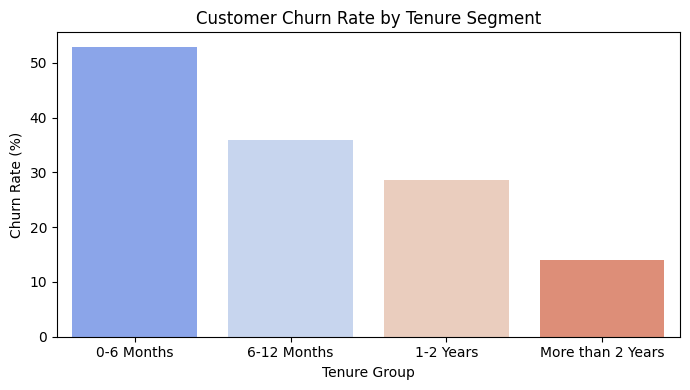

In [25]:
# SQL Query: Bin tenure into cohorts and calculate churn rates
query_tenure = """
SELECT 
    CASE 
        WHEN [Tenure Months] <= 6 THEN '0-6 Months'
        WHEN [Tenure Months] <= 12 THEN '6-12 Months'
        WHEN [Tenure Months] <= 24 THEN '1-2 Years'
        ELSE 'More than 2 Years'
    END AS Tenure_Cohort,
    COUNT(CustomerID) AS Total_Customers,
    SUM([Churn Value]) AS Churned_Customers,
    ROUND((CAST(SUM([Churn Value]) AS REAL) / COUNT(CustomerID)) * 100, 2) AS Churn_Rate_Percent
FROM ibm_churn
GROUP BY Tenure_Cohort
ORDER BY Churn_Rate_Percent DESC;
"""

# Fetch and display data without index
tenure_data = pd.read_sql(query_tenure, conn)
display(tenure_data.style.hide())

# Plot the findings
plt.figure(figsize=(7, 4))
sns.barplot(data=tenure_data, x='Tenure_Cohort', y='Churn_Rate_Percent', palette='coolwarm')
plt.title('Customer Churn Rate by Tenure Segment')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

### Insights
1. Customers in the 0–6 months tenure cohort have the highest churn rate of approximately 52%, indicating that a significant number of customers leave shortly after joining the company.

2. Customers with 6–12 months of tenure have a churn rate of approximately 35%, showing a noticeable decline in churn compared to new customers.

3. Customers with 1–2 years of tenure have a churn rate of approximately 28%, suggesting that customer loyalty increases as their relationship with the company grows.

4. Customers with more than 2 years of tenure have the lowest churn rate of approximately 14%, nearly half the churn rate of the 1–2 years tenure group, highlighting the strong impact of long-term customer retention.

Internet Service,Total_Customers,Churned_Customers,Churn_Rate_Percent
Fiber optic,3096,1297,41.890000
DSL,2421,459,18.960000
No,1526,113,7.400000


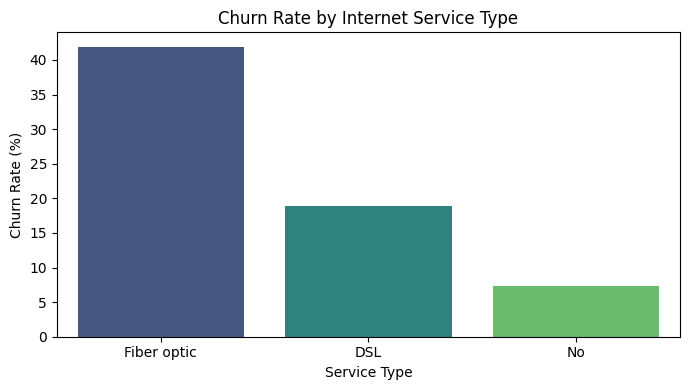

In [26]:
# SQL Query: Calculate customer count and churn rate per Internet Service type
query_internet = """
SELECT 
    [Internet Service],
    COUNT(CustomerID) AS Total_Customers,
    SUM([Churn Value]) AS Churned_Customers,
    ROUND((CAST(SUM([Churn Value]) AS REAL) / COUNT(CustomerID)) * 100, 2) AS Churn_Rate_Percent
FROM ibm_churn
GROUP BY [Internet Service]
ORDER BY Churn_Rate_Percent DESC;
"""

# Fetch and display data without index
internet_data = pd.read_sql(query_internet, conn)
display(internet_data.style.hide())

# Plot the findings
plt.figure(figsize=(7, 4))
sns.barplot(data=internet_data, x='Internet Service', y='Churn_Rate_Percent', palette='viridis')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Service Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

### Insights
1. Customers using Fiber Optic internet service have the highest churn rate of approximately 41.89%, making them the most likely customer segment to leave the company. This indicates a need for targeted retention strategies for Fiber Optic users.

2. Customers with DSL internet service have a churn rate of approximately 18.96%, which is significantly lower than Fiber Optic customers, suggesting better customer retention.

3. Customers without an internet service subscription have the lowest churn rate of approximately 7.40%, highlighting their strong loyalty and low likelihood of churning.

4. The analysis indicates that churn varies significantly by Internet Service type, with Fiber Optic customers being over twice as likely to churn as
DSL customers and nearly six times more likely to churn than customers without internet service.

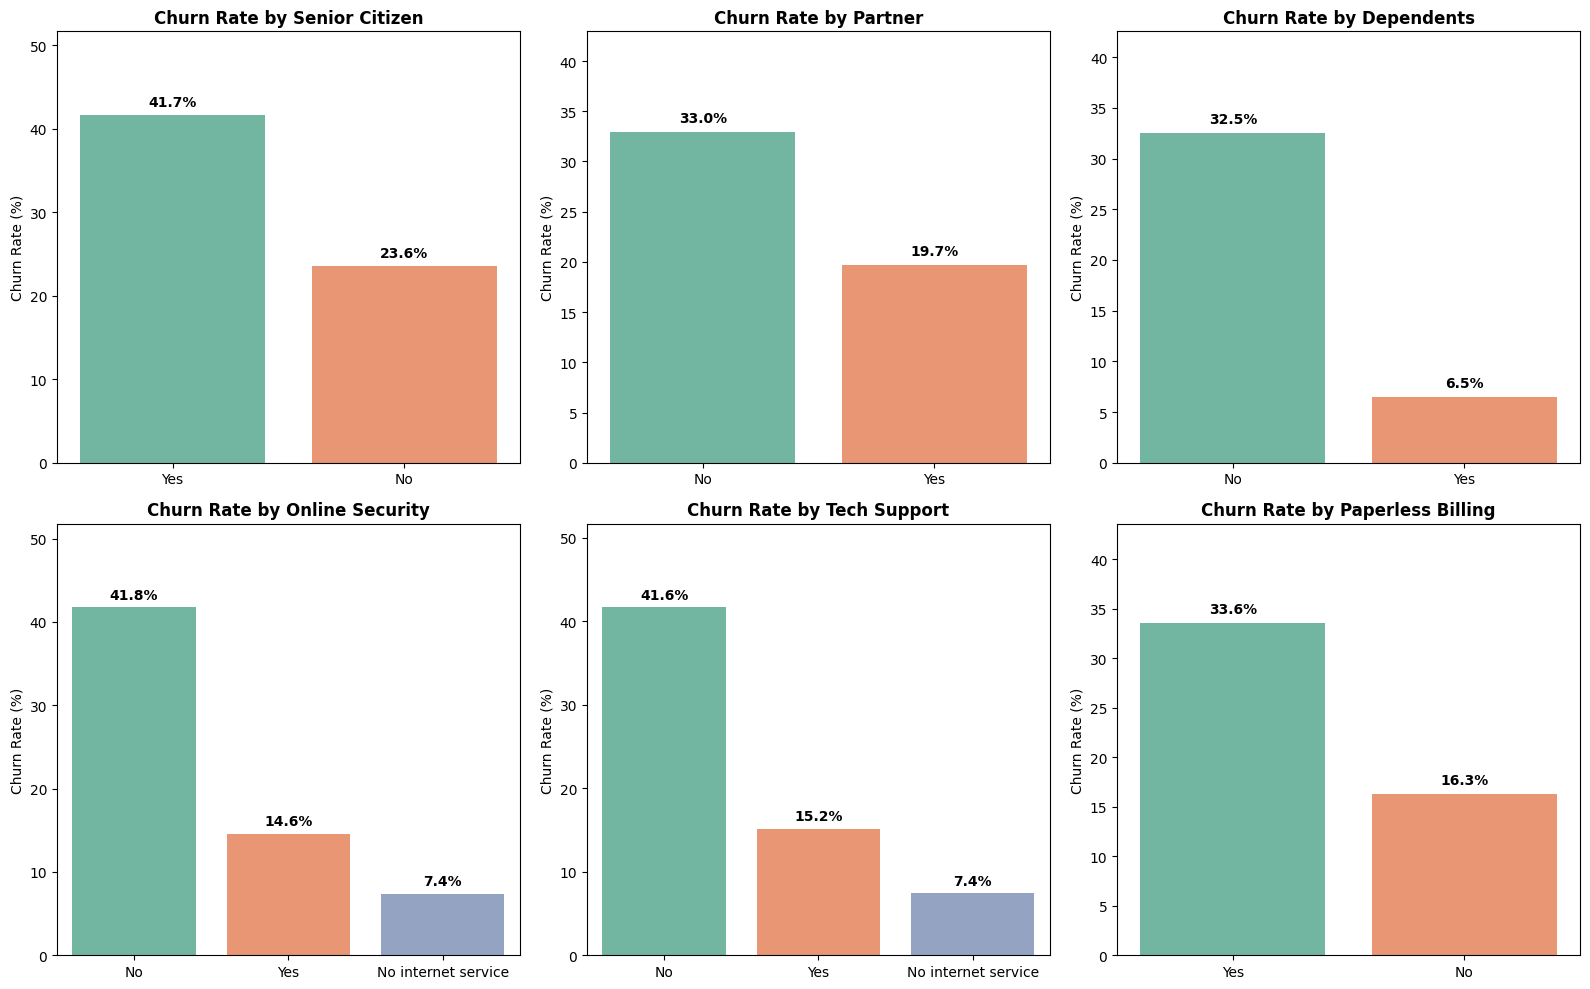

In [27]:
# 1. Define the list of Yes/No columns to analyze
binary_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Online Security', 'Tech Support', 'Paperless Billing']

# 2. Set up a grid of plots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 3. Loop through each column, run the SQL query, and plot the result
for i, col in enumerate(binary_cols):
    # Dynamic SQL query targeting each column
    query = f"""
    SELECT 
        [{col}] AS Column_Value,
        COUNT(CustomerID) AS Total_Customers,
        ROUND((CAST(SUM([Churn Value]) AS REAL) / COUNT(CustomerID)) * 100, 2) AS Churn_Rate_Percent
    FROM ibm_churn
    GROUP BY [{col}]
    ORDER BY Churn_Rate_Percent DESC;
    """
    
    # Run query and get DataFrame
    temp_df = pd.read_sql(query, conn)
    
    # Plot on the corresponding subplot axis
    sns.barplot(
        data=temp_df, 
        x='Column_Value', 
        y='Churn_Rate_Percent', 
        ax=axes[i], 
        palette='Set2'
    )
    
    # Add data labels on top of each bar
    for idx, row in temp_df.iterrows():
        axes[i].text(
            idx, 
            row['Churn_Rate_Percent'] + 1, 
            f"{row['Churn_Rate_Percent']:.1f}%", 
            ha='center', 
            fontweight='bold',
            fontsize=10
        )
    
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, temp_df['Churn_Rate_Percent'].max() + 10)

plt.tight_layout()
plt.show()

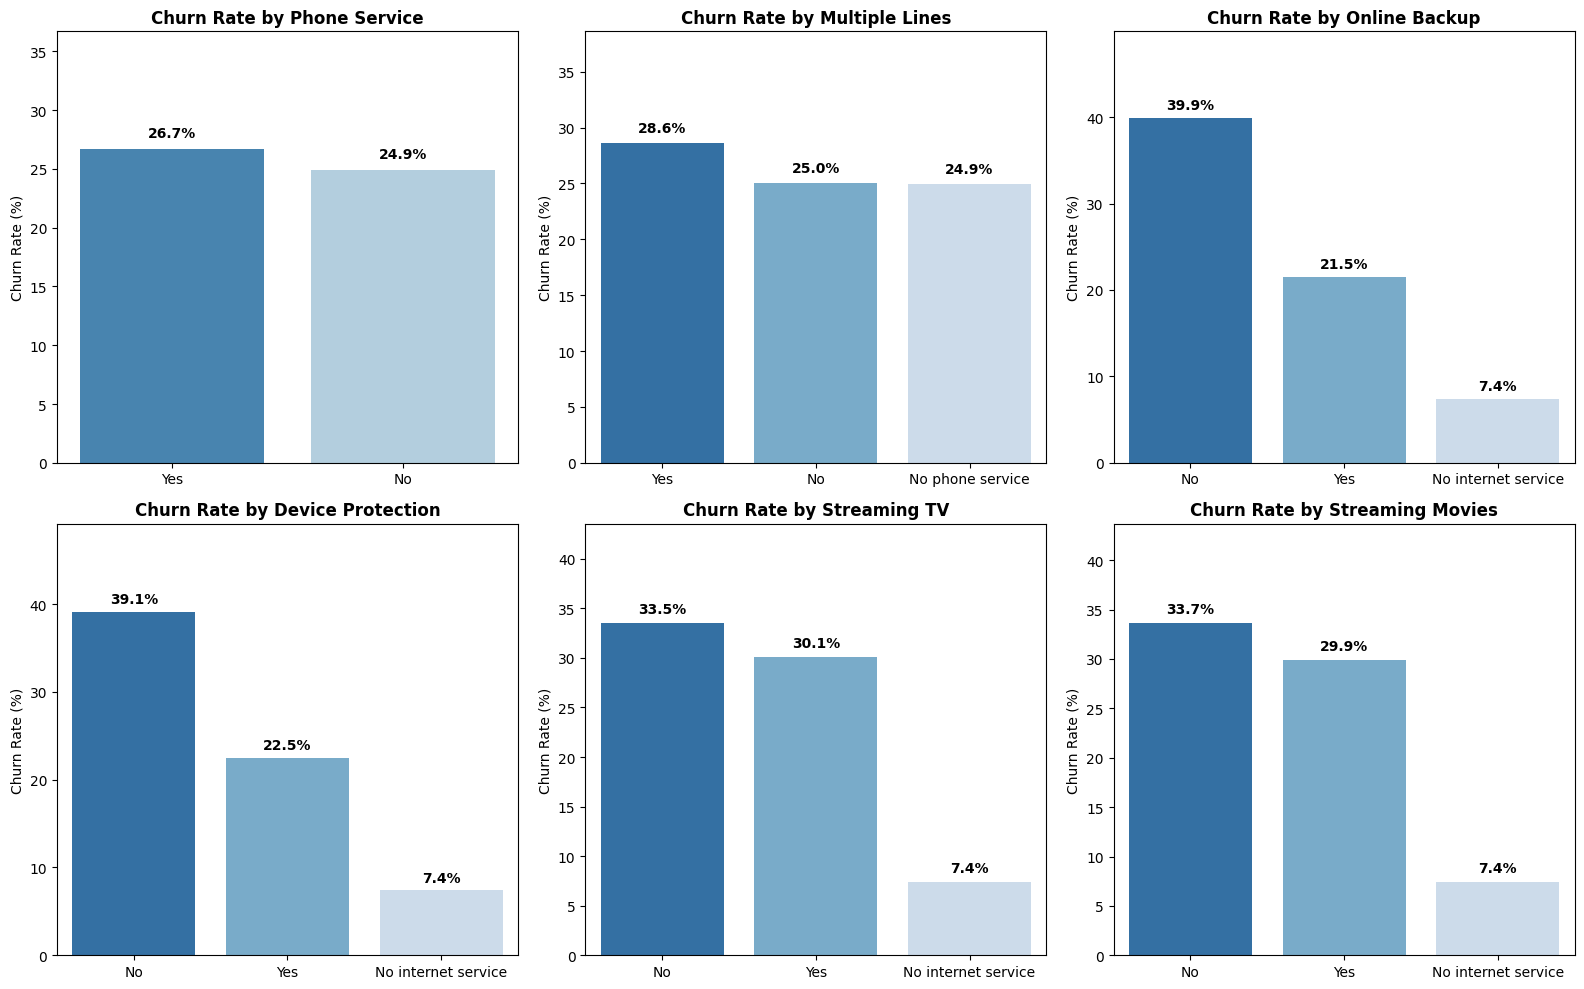

In [28]:
# 1. Define the next set of service columns (corrected 'Phone Service')
binary_cols_2 = ['Phone Service', 'Multiple Lines', 'Online Backup', 'Device Protection', 'Streaming TV', 'Streaming Movies']

# 2. Set up a grid of plots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 3. Loop through each column, run the SQL query, and plot the result
for i, col in enumerate(binary_cols_2):
    # Dynamic SQL query targeting each column
    query = f"""
    SELECT 
        [{col}] AS Column_Value,
        COUNT(CustomerID) AS Total_Customers,
        ROUND((CAST(SUM([Churn Value]) AS REAL) / COUNT(CustomerID)) * 100, 2) AS Churn_Rate_Percent
    FROM ibm_churn
    GROUP BY [{col}]
    ORDER BY Churn_Rate_Percent DESC;
    """
    
    # Run query and get DataFrame
    temp_df = pd.read_sql(query, conn)
    
    # Plot on the corresponding subplot axis
    sns.barplot(
        data=temp_df, 
        x='Column_Value', 
        y='Churn_Rate_Percent', 
        ax=axes[i], 
        palette='Blues_r'
    )
    
    # Add data labels on top of each bar
    for idx, row in temp_df.iterrows():
        axes[i].text(
            idx, 
            row['Churn_Rate_Percent'] + 1, 
            f"{row['Churn_Rate_Percent']:.1f}%", 
            ha='center', 
            fontweight='bold',
            fontsize=10
        )
    
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, temp_df['Churn_Rate_Percent'].max() + 10)

plt.tight_layout()
plt.show()

### Analyzing Top Churn Reasons

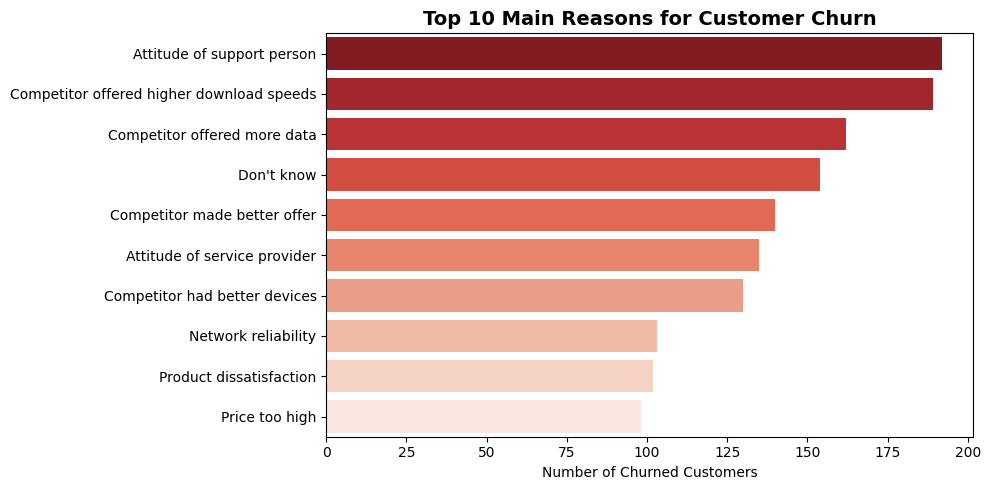

In [29]:
# SQL Query: Get top reasons for churn
query_reasons = """
SELECT 
    [Churn Reason],
    COUNT(CustomerID) AS Churn_Count
FROM ibm_churn
WHERE [Churn Value] = 1 AND [Churn Reason] IS NOT NULL
GROUP BY [Churn Reason]
ORDER BY Churn_Count DESC
LIMIT 10;
"""

reasons_df = pd.read_sql(query_reasons, conn)

# Plotting a clean horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=reasons_df, 
    x='Churn_Count', 
    y='Churn Reason', 
    palette='Reds_r'
)
plt.title('Top 10 Main Reasons for Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Number of Churned Customers')
plt.ylabel('')
plt.tight_layout()
plt.show()

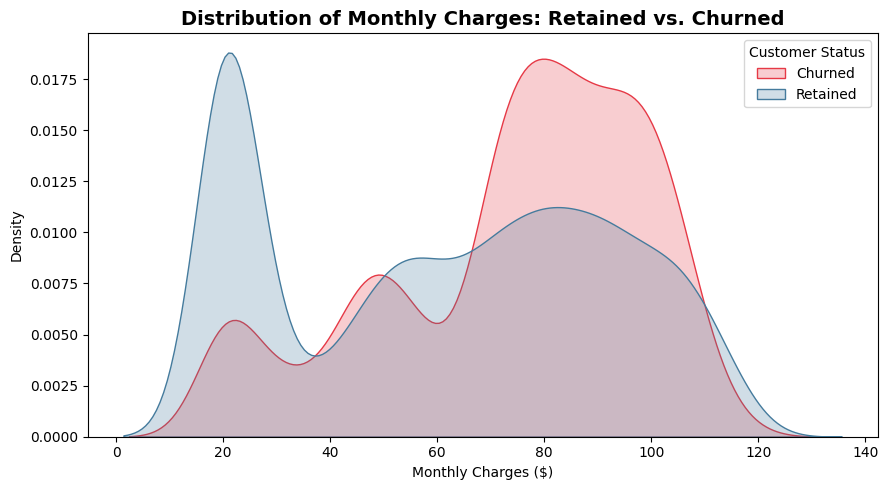

In [30]:
plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=clean_df, 
    x='Monthly Charges', 
    hue='Churn Value', 
    fill=True, 
    common_norm=False, 
    palette=['#457B9D', '#E63946']
)
plt.title('Distribution of Monthly Charges: Retained vs. Churned', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
# Map Legend values
plt.legend(title='Customer Status', labels=['Churned', 'Retained'])
plt.tight_layout()
plt.show()

### Insights
1. The distribution shows that customers with higher monthly charges, particularly those paying between 80 and 100 per month, have the highest churn rate. This suggests that higher monthly charges are strongly associated with an increased likelihood of customer churn.

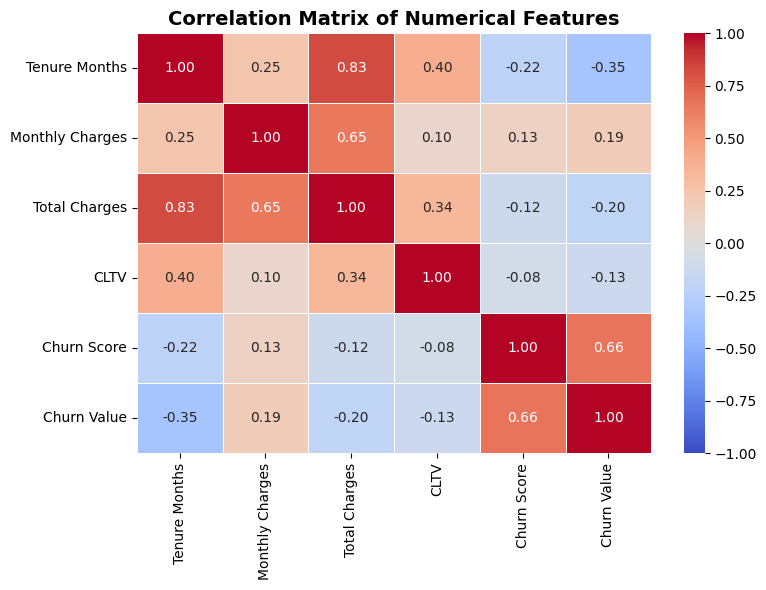

In [31]:
# 1. Select the key numerical columns
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score', 'Churn Value']
corr_matrix = clean_df[numerical_cols].corr()

# 2. Draw the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

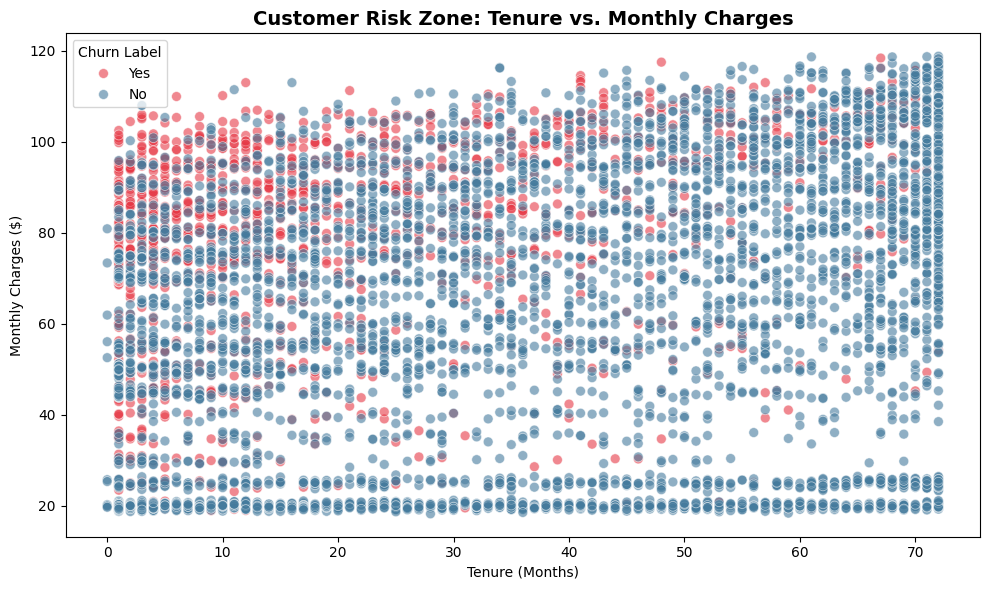

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean_df, 
    x='Tenure Months', 
    y='Monthly Charges', 
    hue='Churn Label', 
    palette={'Yes': '#E63946', 'No': '#457B9D'}, # Red for Churn, Blue for Retained
    alpha=0.6, # Makes dots slightly transparent to see overlaps
    s=50 # Dot size
)
plt.title('Customer Risk Zone: Tenure vs. Monthly Charges', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

### Insights
1. The scatter plot indicates that customer churn is highest during the first year of tenure, suggesting that newly acquired customers are at the greatest risk of leaving the company.

2. Customers with higher monthly charges, particularly during their early months of service, exhibit a higher likelihood of churn, indicating that pricing is a key factor influencing customer retention.

3. Customers who remain with the company for a longer period are significantly less likely to churn, demonstrating that customer loyalty increases with tenure.

4. The highest-risk customer segment consists of customers with less than one year of tenure and relatively high monthly charges. These customers should be prioritized for targeted retention strategies to reduce churn and protect revenue.

In [33]:
# SQL Query to segment active customers and count them
risk_segment_query = """
SELECT 
    CASE 
        WHEN [Churn Score] >= 75 THEN 'High Risk (>=75)'
        WHEN [Churn Score] >= 50 AND [Churn Score] < 75 THEN 'Medium Risk (50-74)'
        ELSE 'Low Risk (<50)'
    END AS Risk_Segment,
    COUNT(CustomerID) AS Active_Customer_Count,
    ROUND(AVG([Monthly Charges]), 2) AS Avg_Monthly_Charges,
    ROUND(SUM([Monthly Charges]), 2) AS Total_Monthly_Revenue_At_Risk
FROM ibm_churn
WHERE [Churn Value] = 0 -- Only focus on currently active customers
GROUP BY Risk_Segment
ORDER BY Risk_Segment;
"""

# Execute and display the results
active_risk_df = pd.read_sql(risk_segment_query, conn)
active_risk_df

,Risk_Segment,Active_Customer_Count,Avg_Monthly_Charges,Total_Monthly_Revenue_At_Risk
0,High Risk (>=75),521,61.02,31793.70
1,Low Risk (<50),2533,60.95,154397.85
2,Medium Risk (50-74),2120,61.70,130794.20


In [34]:
# SQL Query to find Top 10 cities with the highest churn rate (minimum 30 customers)
geo_churn_query = """
SELECT 
    City,
    COUNT(CustomerID) AS Total_Customers,
    SUM([Churn Value]) AS Churned_Customers,
    ROUND((CAST(SUM([Churn Value]) AS REAL) / COUNT(CustomerID)) * 100, 2) AS Churn_Rate_Percent,
    ROUND(SUM(CASE WHEN [Churn Value] = 1 THEN [Total Charges] ELSE 0 END), 2) AS Total_Revenue_Lost
FROM ibm_churn
GROUP BY City
HAVING Total_Customers >= 30  -- Filter for statistical relevance
ORDER BY Churn_Rate_Percent DESC
LIMIT 10;
"""

# Execute and display the results
geo_churn_df = pd.read_sql(geo_churn_query, conn)
geo_churn_df

,City,Total_Customers,Churned_Customers,Churn_Rate_Percent,Total_Revenue_Lost
0,San Diego,150,50,33.33,80261.40
1,Glendale,40,13,32.50,9223.25
2,Pasadena,30,9,30.00,20967.05
3,San Francisco,104,31,29.81,44485.45
4,Los Angeles,305,90,29.51,126298.25
5,Berkeley,32,9,28.13,6300.85
6,Stockton,44,12,27.27,15211.90
7,San Jose,112,29,25.89,34967.20
8,Riverside,32,8,25.00,5507.95
9,Oakland,52,13,25.00,16996.55


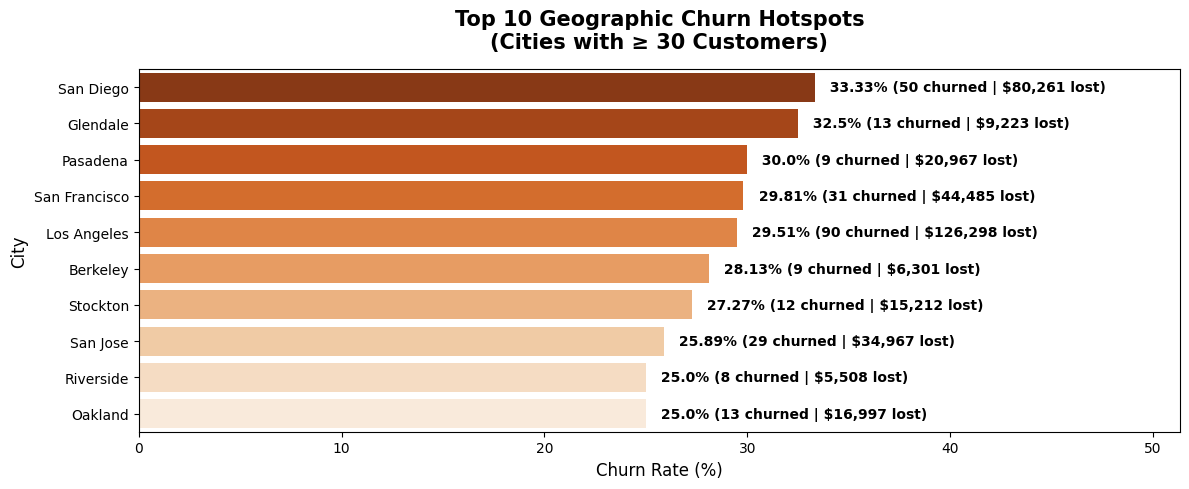

In [35]:
plt.figure(figsize=(12, 5))

# Plot Churn Rates by City
sns.barplot(
    data=geo_churn_df, 
    x='Churn_Rate_Percent', 
    y='City', 
    palette='Oranges_r'
)

# Annotate each bar with its respective count and financial loss
for index, row in geo_churn_df.iterrows():
    label_text = f" {row['Churn_Rate_Percent']}% ({int(row['Churned_Customers'])} churned | ${row['Total_Revenue_Lost']:,.0f} lost)"
    plt.text(
        row['Churn_Rate_Percent'] + 0.5, 
        index, 
        label_text, 
        va='center', 
        fontweight='bold', 
        fontsize=10
    )

plt.title('Top 10 Geographic Churn Hotspots\n(Cities with ≥ 30 Customers)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xlim(0, geo_churn_df['Churn_Rate_Percent'].max() + 18)  # Leave room for annotations
plt.tight_layout()
plt.show()

In [36]:
# SQL Query to find top reasons for churn in the first 6 months
cohort_reasons_query = """
SELECT 
    [Churn Reason],
    COUNT(CustomerID) AS Churn_Count,
    ROUND((CAST(COUNT(CustomerID) AS REAL) / 
        (SELECT COUNT(*) FROM ibm_churn WHERE [Tenure Months] <= 6 AND [Churn Value] = 1)) * 100, 2) AS Percentage_of_Cohort_Churn
FROM ibm_churn
WHERE [Tenure Months] <= 6 
  AND [Churn Value] = 1 
  AND [Churn Reason] IS NOT NULL
GROUP BY [Churn Reason]
ORDER BY Churn_Count DESC
LIMIT 5;
"""

# Execute and display the results
cohort_reasons_df = pd.read_sql(cohort_reasons_query, conn)
cohort_reasons_df

,Churn Reason,Churn_Count,Percentage_of_Cohort_Churn
0,Attitude of support person,80,10.20
1,Don't know,72,9.18
2,Competitor offered higher download speeds,72,9.18
3,Competitor had better devices,64,8.16
4,Competitor made better offer,63,8.04


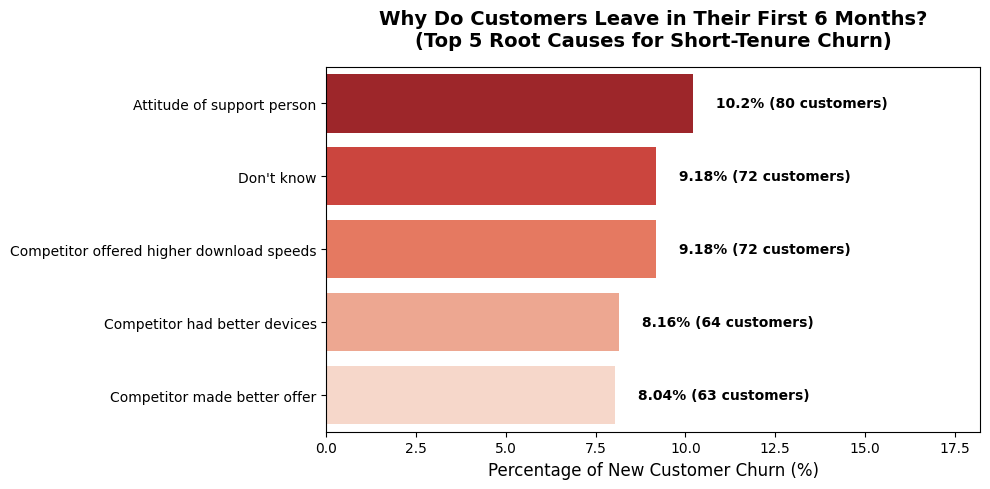

In [37]:
plt.figure(figsize=(10, 5))

# Plot the top reasons
sns.barplot(
    data=cohort_reasons_df, 
    x='Percentage_of_Cohort_Churn', 
    y='Churn Reason', 
    palette='Reds_r'
)

# Add value labels to the end of each bar
for index, row in cohort_reasons_df.iterrows():
    plt.text(
        row['Percentage_of_Cohort_Churn'] + 0.5, 
        index, 
        f" {row['Percentage_of_Cohort_Churn']}% ({int(row['Churn_Count'])} customers)", 
        va='center', 
        fontweight='bold',
        fontsize=10
    )

plt.title('Why Do Customers Leave in Their First 6 Months?\n(Top 5 Root Causes for Short-Tenure Churn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of New Customer Churn (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, cohort_reasons_df['Percentage_of_Cohort_Churn'].max() + 8)  # Leave room for text labels
plt.tight_layout()
plt.show()

# 💡 Simple Recommendations to Keep Customers

Based on the analysis, here are **4 straightforward steps** the company should take to stop losing customers and protect revenue:

---

### 1. 🤝 Fix the First 90 Days (New Customer Onboarding)
* **What’s happening:** Over half of all lost customers leave in their first 6 months, often because of bad experiences with customer support staff.
* **What to do:**
  * Reach out to new customers with helpful check-in calls or emails at 30, 60, and 90 days.
  * Train customer service reps to be more friendly and patient when dealing with new subscribers.

---

### 2. ⚡ Improve Fiber Optic Internet Quality
* **What’s happening:** Over 40% of Fiber Optic users leave—mostly switching to competitors who offer better speeds or newer equipment.
* **What to do:**
  * Test and upgrade Fiber Optic lines so customer speeds are fast and reliable.
  * Include free extra services like **Tech Support** or **Online Security** with Fiber Optic plans to add extra value.

---

### 3. 💳 Offer Small Discounts for Auto-Pay & Contracts
* **What’s happening:** Month-to-month subscribers and people paying with Electronic Checks account for the largest chunk of lost revenue.
* **What to do:**
  * Give a **$5 to $10 monthly discount** to customers who sign up for **Automatic Payments** (Bank Transfer or Credit Card).
  * Offer small discounts to encourage people to sign up for 1-year or 2-year contracts instead of month-to-month plans.

---

### 4. 🛡️ Include Security & Tech Support in Standard Plans
* **What’s happening:** Customers who do not have Tech Support or Online Security leave at much higher rates.
* **What to do:**
  * Bundle basic **Online Security** and **Tech Support** automatically into standard packages instead of selling them as expensive add-ons.